# Exploratory Data Analysis (CIC-IDS2017)

[Dataset Link](https://www.unb.ca/cic/datasets/ids-2017.html)

# CICIDS2017: Visão Geral

O CICIDS2017 é um conjunto de dados desenvolvido pelo Canadian Institute for Cybersecurity para pesquisas em detecção de intrusões. Ele combina tráfego benigno realista com ataques simulados, permitindo avaliações controladas e comparáveis de métodos de análise e defesa em redes.

## Características Principais

- Milhões de fluxos de rede com cerca de 80 atributos por fluxo.
- Coleta realizada ao longo de cinco dias, cada um contendo diferentes cenários de tráfego e ataques.
- Disponível em PCAP e em versões CSV pré-processadas, amplamente utilizadas em machine learning.
- Atributos incluem estatísticas de pacotes, taxas de transferência, flags de protocolo e métricas temporais.

## Relevância Científica

O dataset tornou-se referência por oferecer diversidade de ataques, rotulagem confiável e cenário próximo de redes reais. É adequado para estudos supervisionados, não supervisionados e híbridos, facilitando comparações reprodutíveis entre diferentes abordagens de detecção de intrusões.

## Limitações

- Desbalanceamento entre classes, especialmente em ataques raros.
- Ambiente controlado que não incorpora toda a complexidade de redes corporativas reais.
- Alguns ataques são simulados de forma automatizada, podendo simplificar certos padrões comportamentais.

## Tipos de Ataques 

### Força Bruta
Ataques baseados em tentativas repetidas de adivinhar credenciais de acesso, como FTP e SSH, explorando repetição rápida e automatizada.

### Scanning
Processos de reconhecimento que identificam portas abertas, serviços ativos e potenciais vulnerabilidades. Costumam preceder etapas de intrusão.

### DDoS e DoS
Ataques que sobrecarregam serviços com tráfego excessivo, causando indisponibilidade. Incluem variantes de alta taxa (Hulk, GoldenEye) e variantes lentas (Slowloris, SlowHTTPTest).

### Ataques Web
Exploram vulnerabilidades em aplicações web, como injeção de comandos ou scripts maliciosos (XSS), visando comprometer sistemas pela camada de aplicação.

### Botnet
Atividade típica de máquinas comprometidas que se comunicam com servidores de comando e controlo e executam ações automatizadas.

### Exploits Específicos
Explorações direcionadas a vulnerabilidades concretas, como o Heartbleed, que permitia extrair dados sensíveis da memória de sistemas com OpenSSL vulnerável.


In [1]:
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
sns.set(style='darkgrid')

# pd.set_option('display.max_columns', 50)
# pd.set_option('display.width', 1000)
# sns.set(style="whitegrid")

DATA_PATH = "data/processed/CICIDS2017"

df = dd.read_parquet(DATA_PATH)


### Sample do Dataset

In [ ]:
sample_df = df.sample(frac=0.1, random_state=42).compute()
sample_df.head(n=100)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
161006,80,1746017,3,5,26,11607,20,0,8.666666667,10.26320288,...,20,0,0,0,0,0,0,0,0,DDoS
144094,80,345891,3,4,26,11601,20,0,8.666666667,10.26320288,...,20,0,0,0,0,0,0,0,0,DDoS
164085,80,33067,3,6,26,11601,20,0,8.666666667,10.26320288,...,20,0,0,0,0,0,0,0,0,DDoS
209114,443,5171092,5,1,135,46,46,6,27,20.1246118,...,20,93430,0,93430,93430,5047735,0,5047735,5047735,BENIGN
68594,80,80349592,8,4,56,11607,20,0,7,5.656854249,...,20,2013,0,2013,2013,39200000,38400000,66400000,12100000,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84435,80,81203155,9,4,62,11601,20,0,6.888888889,5.30199124,...,20,37018,0,37018,37018,80700000,0,80700000,80700000,DDoS
56320,80,1449695,3,5,26,11607,20,0,8.666666667,10.26320288,...,20,0,0,0,0,0,0,0,0,DDoS
144940,80,3473925,5,0,30,0,6,6,6,0,...,20,0,0,0,0,0,0,0,0,DDoS
141011,80,920914,3,6,26,11601,20,0,8.666666667,10.26320288,...,20,0,0,0,0,0,0,0,0,DDoS


### Dimensão do Dataset

In [3]:
rows = df.shape[0].compute()
cols = df.shape[1]

print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')


Number of rows: 2830743
Number of columns: 79
Total cells: 223628697


In [4]:
df.compute().info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830743 entries, 0 to 259280
Data columns (total 79 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0    Destination Port             string
 1    Flow Duration                string
 2    Total Fwd Packets            string
 3    Total Backward Packets       string
 4   Total Length of Fwd Packets   string
 5    Total Length of Bwd Packets  string
 6    Fwd Packet Length Max        string
 7    Fwd Packet Length Min        string
 8    Fwd Packet Length Mean       string
 9    Fwd Packet Length Std        string
 10  Bwd Packet Length Max         string
 11   Bwd Packet Length Min        string
 12   Bwd Packet Length Mean       string
 13   Bwd Packet Length Std        string
 14  Flow Bytes/s                  string
 15   Flow Packets/s               string
 16   Flow IAT Mean                string
 17   Flow IAT Std                 string
 18   Flow IAT Max                 string
 19   Flow 

##### Todas as features são do tipo string

In [5]:
# Percentagem de valores nulos por coluna
nulls = (df.isnull().mean() * 100).compute().sort_values(ascending=False)
# Mostrar apenas colunas com valores nulos
print(nulls[nulls > 0])


Flow Bytes/s    0.047973
dtype: float64


In [6]:
# tamanho total
total = df.shape[0].compute()

# número de ocorrências de cada linha
counts = df.map_partitions(lambda pdf: pdf.value_counts()).compute()

# total de duplicados (ocorrências > 1)
duplicated_rows = counts[counts > 1].sum() - counts[counts > 1].size

dup_ratio = duplicated_rows / total
print(f"Duplicados: {dup_ratio:.2%}")


Duplicados: 8.66%


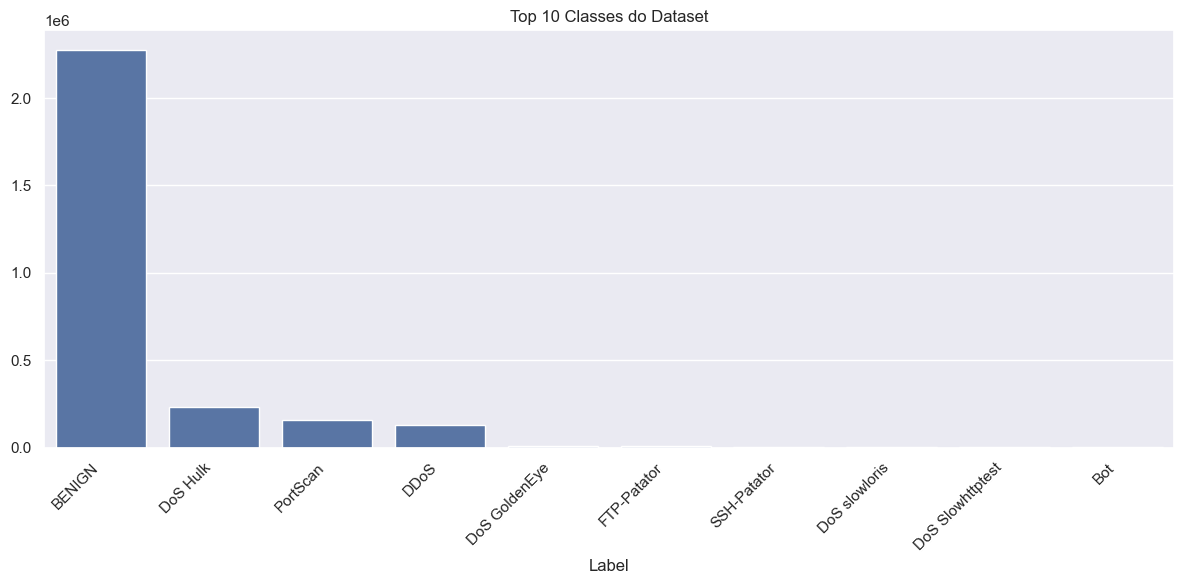

In [7]:
# Remove espaços antes e depois de todos os nomes de colunas
df.columns = df.columns.str.strip()

# Convert to pandas first for value_counts and handle string column
labels = df['Label'].astype(str).compute().value_counts()
top_n = 10
labels_top = labels.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(12,6))
sns.barplot(x=labels_top.index, y=labels_top.values)
plt.title(f"Top {top_n} Classes do Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Estatísticas das colunas numéricas
df.describe().compute().T.head(100)


,unique,count,top,freq
Destination Port,53805,2830743,53,957971
Flow Duration,1050899,2830743,3,90197
Total Fwd Packets,1432,2830743,2,1073079
Total Backward Packets,1747,2830743,1,793931
Total Length of Fwd Packets,17928,2830743,0,449170
...,...,...,...,...
Idle Mean,222016,2830743,0,2263460
Idle Std,197616,2830743,0,2601500
Idle Max,149737,2830743,0,2263460
Idle Min,223888,2830743,0,2263460


In [9]:
# Converter Dask → Pandas
encoded = df.compute() if not isinstance(df, pd.DataFrame) else df.copy()
encoded.columns = encoded.columns.str.strip()

# Separar a Label
label_col = encoded['Label'].copy()

# Converter apenas as features para numérico
features = encoded.drop(columns=['Label'], errors='ignore')
for col in features.columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Juntar novamente (mantendo a Label original)
encoded = pd.concat([features, label_col], axis=1)

# Codificar Label (sem alterar as classes originais)
encoded['Label_encoded'] = encoded['Label'].astype('category').cat.codes

# Calcular correlação com Label_encoded
corr_target = encoded.corr(numeric_only=True)['Label_encoded'].sort_values(ascending=False)
corr_target.head(50)

Label_encoded                  1.000000
PSH Flag Count                 0.305413
Fwd IAT Std                    0.205842
Idle Mean                      0.187675
Idle Min                       0.187095
Idle Max                       0.186252
Fwd IAT Max                    0.182371
Bwd Packet Length Std          0.182160
Flow IAT Max                   0.181158
Bwd Packet Length Max          0.171966
Bwd Packet Length Mean         0.158172
Avg Bwd Segment Size           0.158172
Packet Length Variance         0.155879
Flow IAT Std                   0.152930
Packet Length Std              0.151829
Max Packet Length              0.149638
Packet Length Mean             0.111318
Bwd Packets/s                  0.108456
Average Packet Size            0.107143
Init_Win_bytes_forward         0.101153
FIN Flag Count                 0.095890
Bwd IAT Std                    0.075865
Fwd IAT Total                  0.074685
Flow Duration                  0.072592
Flow IAT Mean                  0.065027


                                count      mean       std  min  25%  50%  75%  \
Label                                                                           
PortScan                     158930.0  0.999572   0.02068  0.0  1.0  1.0  1.0   
Web Attack � XSS                652.0  0.964724  0.184618  0.0  1.0  1.0  1.0   
Web Attack � Brute Force       1507.0  0.905109  0.293161  0.0  1.0  1.0  1.0   
DoS Slowhttptest               5499.0  0.766685   0.42298  0.0  1.0  1.0  1.0   
DoS GoldenEye                 10293.0  0.715632  0.451135  0.0  0.0  1.0  1.0   
DoS slowloris                  5796.0  0.668219  0.470893  0.0  0.0  1.0  1.0   
Bot                            1966.0  0.624619  0.484344  0.0  0.0  1.0  1.0   
Web Attack � Sql Injection       21.0  0.571429  0.507093  0.0  0.0  1.0  1.0   
SSH-Patator                    5897.0  0.505172  0.500016  0.0  0.0  1.0  1.0   
FTP-Patator                    7938.0   0.50063  0.500031  0.0  0.0  1.0  1.0   
DDoS                        

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_3004\2619039472.py:20: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


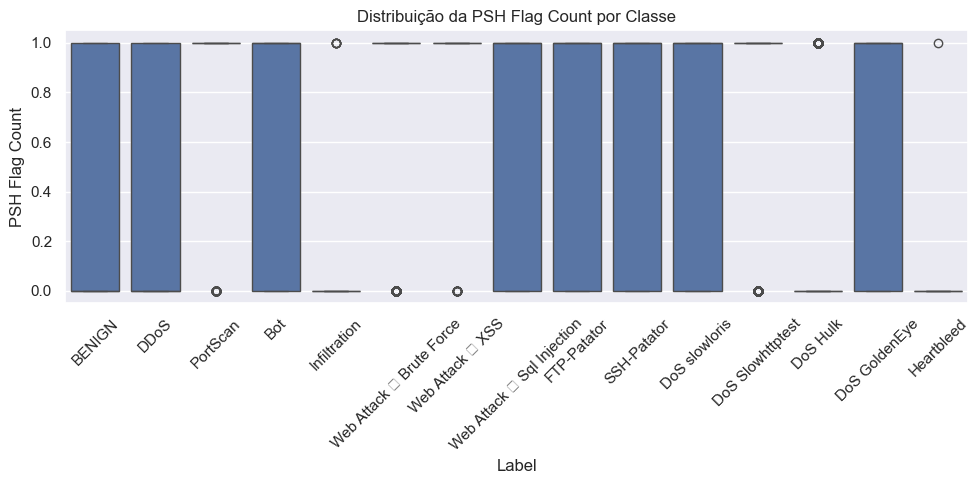

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_3004\2619039472.py:27: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


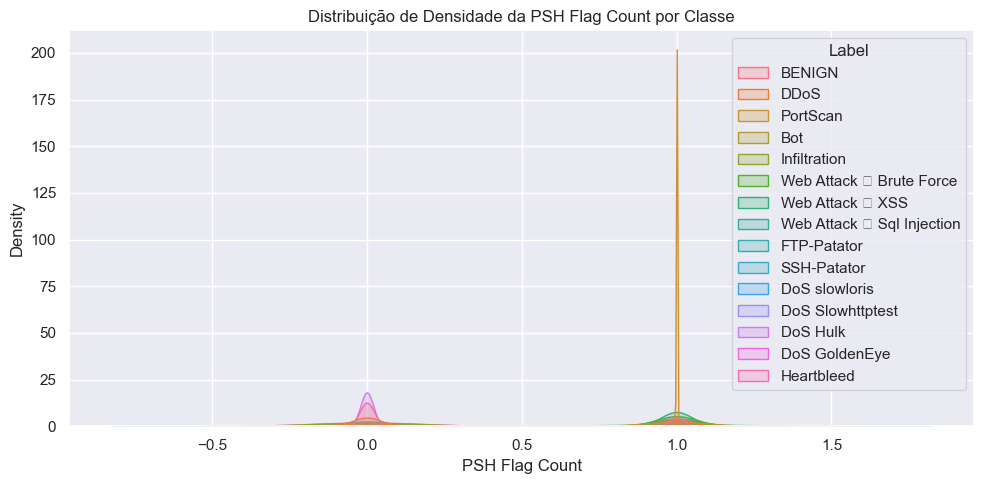

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_3004\2619039472.py:36: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


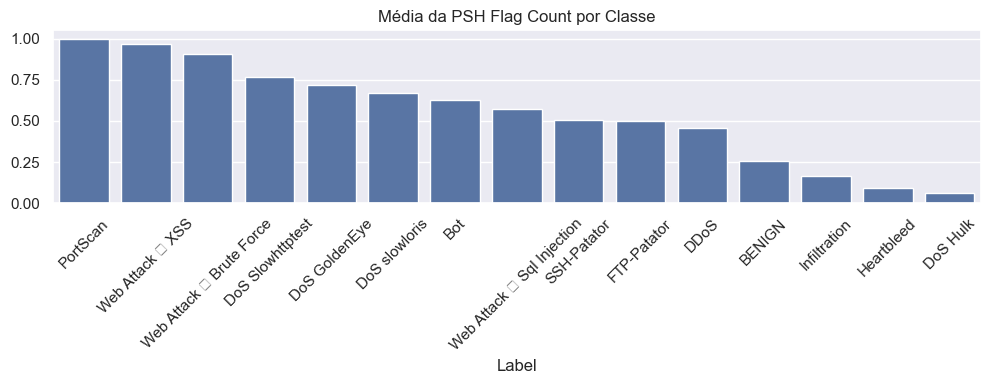

In [10]:
# garantir que Label e PSH Flag Count existem
if 'PSH Flag Count' not in encoded.columns:
    raise KeyError("Coluna 'PSH Flag Count' não encontrada no DataFrame.")

# converter para numérico se necessário
encoded['PSH Flag Count'] = pd.to_numeric(encoded['PSH Flag Count'], errors='coerce')

# remover valores nulos
feat_df = encoded[['Label', 'PSH Flag Count']].dropna()

# estatísticas descritivas por classe
stats = feat_df.groupby('Label')['PSH Flag Count'].describe().sort_values('mean', ascending=False)
print(stats)

# boxplot por classe
plt.figure(figsize=(10,5))
sns.boxplot(data=feat_df, x='Label', y='PSH Flag Count')
plt.title("Distribuição da PSH Flag Count por Classe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# densidade / histograma por classe
plt.figure(figsize=(10,5))
sns.kdeplot(data=feat_df, x='PSH Flag Count', hue='Label', common_norm=False, fill=True)
plt.title("Distribuição de Densidade da PSH Flag Count por Classe")
plt.tight_layout()
plt.show()

# valores médios por classe
plt.figure(figsize=(10,4))
mean_values = feat_df.groupby('Label')['PSH Flag Count'].mean().sort_values(ascending=False)
sns.barplot(x=mean_values.index, y=mean_values.values)
plt.title("Média da PSH Flag Count por Classe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
from scipy.stats import mannwhitneyu

# teste estatístico entre BENIGN e as restantes classes (exemplo)
labels = feat_df['Label'].unique()
if 'BENIGN' in labels:
    benign = feat_df.loc[feat_df['Label'] == 'BENIGN', 'PSH Flag Count']
    for label in labels:
        if label != 'BENIGN':
            attack = feat_df.loc[feat_df['Label'] == label, 'PSH Flag Count']
            stat, p = mannwhitneyu(benign, attack, alternative='two-sided')
            print(f"Teste BENIGN vs {label}: U={stat:.0f}, p={p:.3e}")

Teste BENIGN vs DDoS: U=116921329790, p=0.000e+00
Teste BENIGN vs PortScan: U=46681759568, p=0.000e+00
Teste BENIGN vs Bot: U=1415280667, p=1.294e-301
Teste BENIGN vs Infiltration: U=44653059, p=2.104e-01
Teste BENIGN vs Web Attack � Brute Force: U=604437608, p=0.000e+00
Teste BENIGN vs Web Attack � XSS: U=217332444, p=0.000e+00
Teste BENIGN vs Web Attack � Sql Injection: U=16386956, p=1.029e-03
Teste BENIGN vs FTP-Patator: U=6833009436, p=0.000e+00
Teste BENIGN vs SSH-Patator: U=5045678906, p=0.000e+00
Teste BENIGN vs DoS slowloris: U=3885196010, p=0.000e+00
Teste BENIGN vs DoS Slowhttptest: U=3070712986, p=0.000e+00
Teste BENIGN vs DoS Hulk: U=313805317470, p=0.000e+00
Teste BENIGN vs DoS GoldenEye: U=6344986486, p=0.000e+00
Teste BENIGN vs Heartbleed: U=14591114, p=2.053e-01


#### Patterns

In [12]:
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

df['Attack Type'] = df['Label'].map(attack_map, meta=('Attack Type', 'object'))


df['Attack Type'].value_counts().compute().sort_values(ascending=False)


Attack Type
BENIGN          2273097
DoS              252661
Port Scan        158930
DDoS             128027
Brute Force       13835
Web Attack         2180
Bot                1966
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

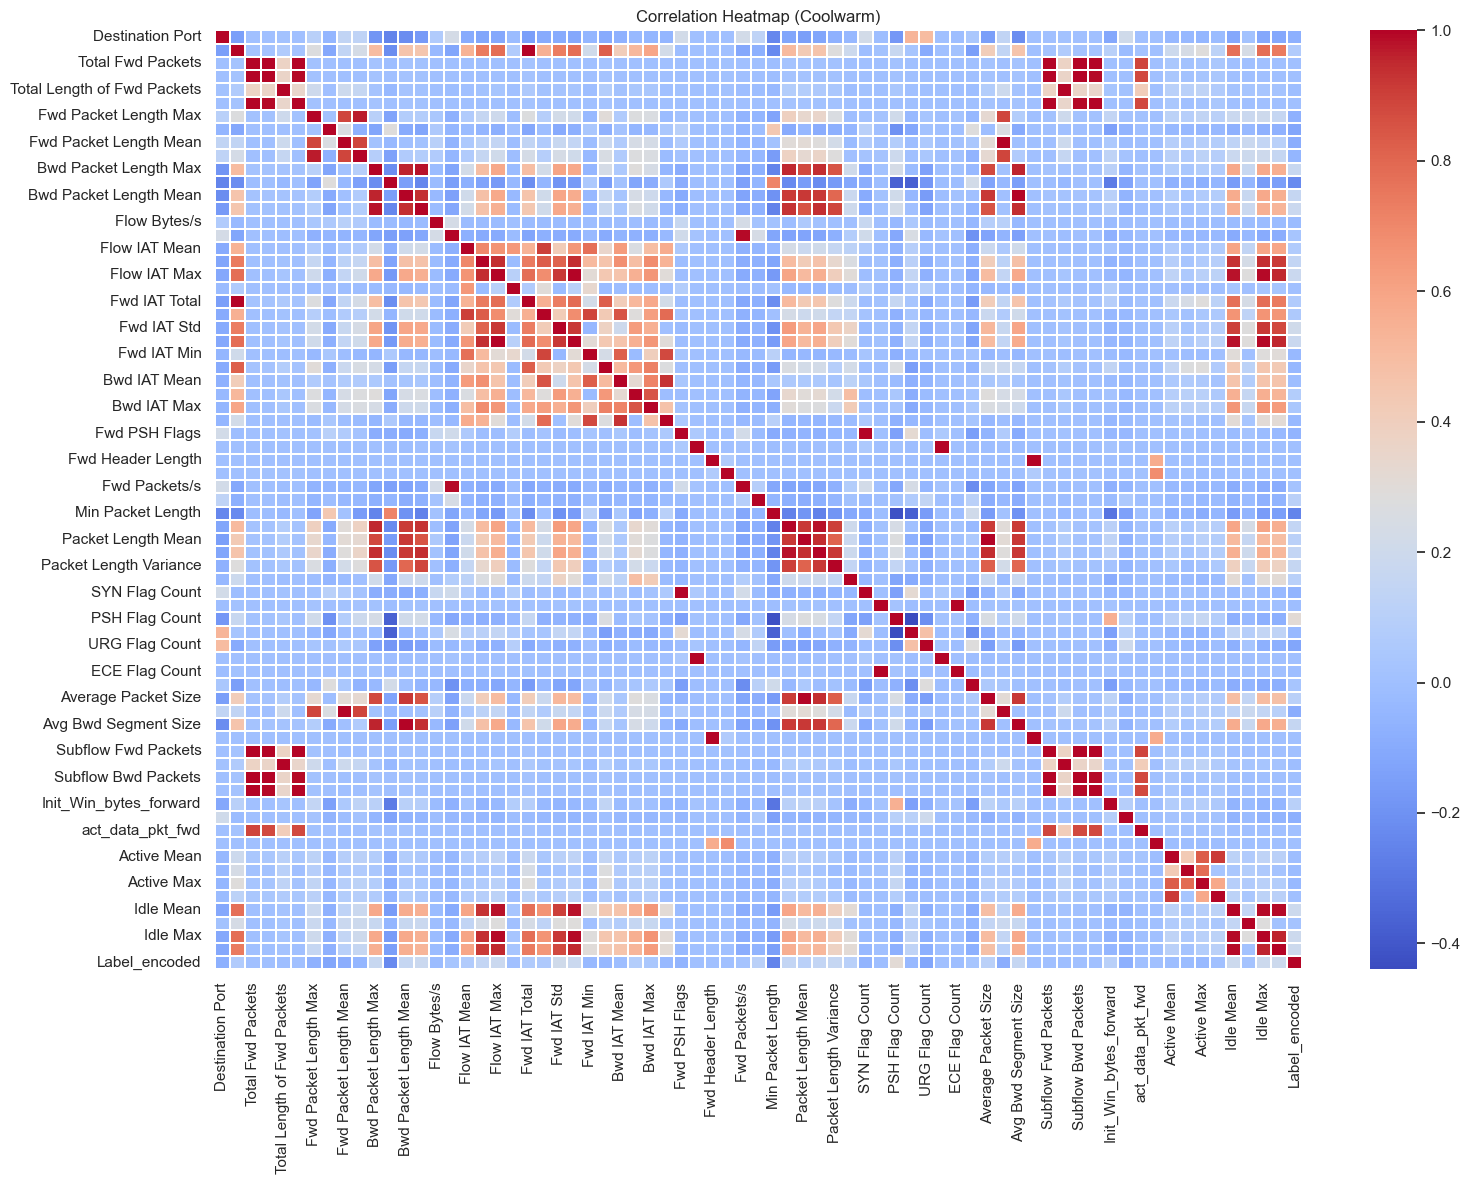

In [38]:
# pdf = df.compute()

# y = pdf["Label"]
# X = pdf.drop(columns=["Label"])
# X = X.apply(pd.to_numeric, errors='coerce')

# pdf_clean = X.copy()
# pdf_clean["Label_encoded"] = y.astype("category").cat.codes

# corr = pdf_clean.corr().round(2)
# corr_clean = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")


plt.figure(figsize=(16, 12))
sns.heatmap(corr_clean, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title("Correlation Heatmap (Coolwarm)")
plt.tight_layout()
plt.show()

In [39]:
corr_target = corr_clean["Label_encoded"].abs().sort_values(ascending=False)
corr_target


Label_encoded            1.00
PSH Flag Count           0.31
Min Packet Length        0.25
Bwd Packet Length Min    0.23
Fwd IAT Std              0.21
                         ... 
Subflow Bwd Bytes        0.00
min_seg_size_forward     0.00
act_data_pkt_fwd         0.00
Subflow Bwd Packets      0.00
Active Min               0.00
Name: Label_encoded, Length: 71, dtype: float64

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_3004\3547327136.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topN.values, y=topN.index, orient='h', palette='coolwarm')


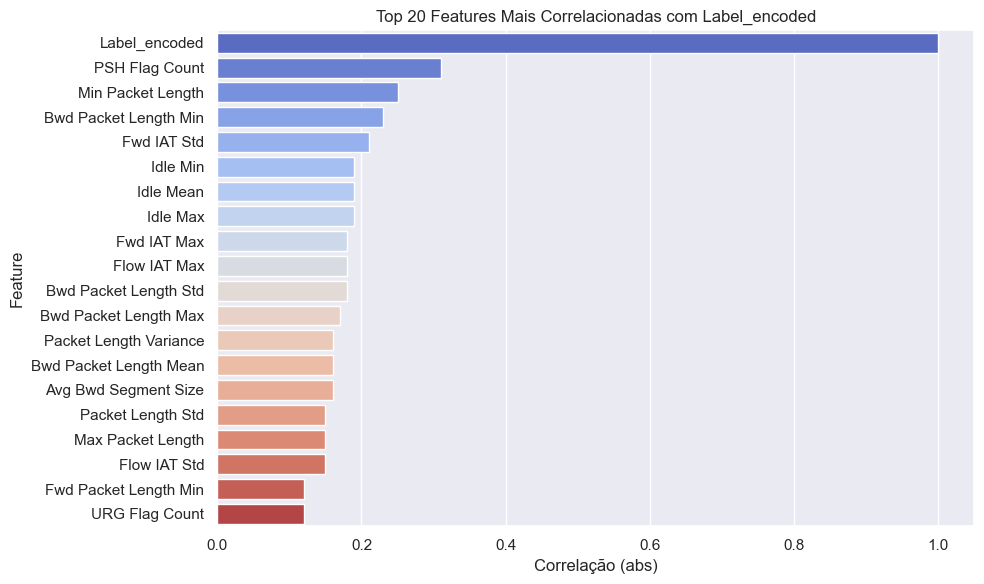

In [40]:
topN = corr_target.head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=topN.values, y=topN.index, orient='h', palette='coolwarm')
plt.title("Top 20 Features Mais Correlacionadas com Label_encoded")
plt.xlabel("Correlação (abs)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


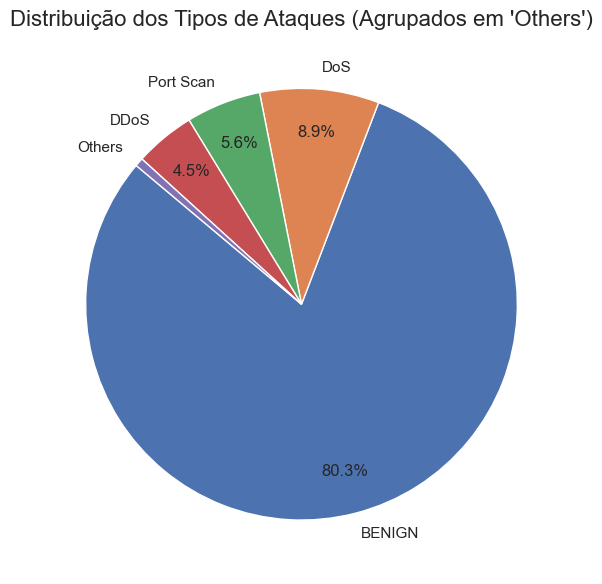

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# 1) Mapa de agrupamento inicial
# =====================================================

attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Criar coluna agrupada
pdf["Attack Type"] = pdf["Label"].map(attack_map)

# =====================================================
# 2) Calcular contagens
# =====================================================

counts = pdf["Attack Type"].value_counts()

# =====================================================
# 3) Aplicar threshold → categorias pequenas → "Others"
# =====================================================

threshold = 0.005   # 0,5% do dataset (ajusta como quiseres)

total = counts.sum()
small_classes = counts[counts < total * threshold].index

# Substituir classes pequenas por "Others"
pdf["Attack Grouped"] = pdf["Attack Type"].replace({c: "Others" for c in small_classes})

# Contagem final
counts_grouped = pdf["Attack Grouped"].value_counts()

# =====================================================
# 4) Pie Chart Melhorado
# =====================================================

explode = [0.05 if v < counts_grouped.sum()*0.05 else 0 for v in counts_grouped]

plt.figure(figsize=(6, 6))
plt.pie(
    counts_grouped.values,
    labels=counts_grouped.index,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)

plt.title("Distribuição dos Tipos de Ataques (Agrupados em 'Others')", fontsize=16)
plt.tight_layout()
plt.show()


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_3004\336815744.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attacks_only["Attack Grouped"] = attacks_only["Attack Type"].replace(


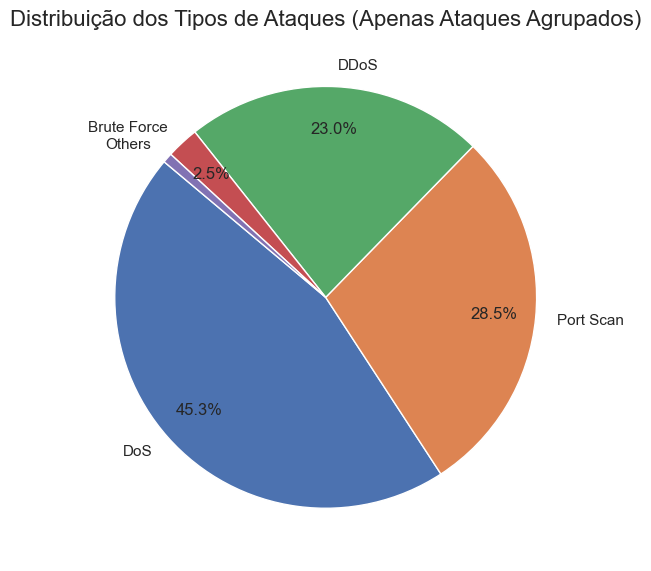

In [76]:

attacks_only = pdf[pdf["Attack Type"] != "BENIGN"]

# Contagens
counts = attacks_only["Attack Type"].value_counts()

# =====================================================
# 3) Threshold → classes pequenas viram "Others"
# =====================================================

threshold = 0.005  # 2% dos ataques

total = counts.sum()
small_classes = counts[counts < total * threshold].index

# Criar coluna final agrupada
attacks_only["Attack Grouped"] = attacks_only["Attack Type"].replace(
    {c: "Others" for c in small_classes}
)

counts_grouped = attacks_only["Attack Grouped"].value_counts()

# =====================================================
# 4) Gráfico de Pizza – apenas ataques
# =====================================================


plt.figure(figsize=(6, 6))
plt.pie(
    counts_grouped.values,
    labels=counts_grouped.index,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)

plt.title("Distribuição dos Tipos de Ataques (Apenas Ataques Agrupados)", fontsize=16)
plt.tight_layout()
plt.show()
